In [1]:
!pip install PyPDF2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 3.7 MB/s eta 0:00:00a 0:00:01


In [2]:
!pip install pyspellchecker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 43.5 MB/s eta 0:00:0000:0100:01


In [3]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 36.9 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.14.0
    Uninstalling scipy-1.14.0:
      Successfully uninstalled scipy-1.14.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
libpysal 4.9.2 requires packaging>=22, but you have packaging 21.3 which is incompatible.
libpysal 4.9.2 requires shapely>=2.0.1, but you have shapely 1.8.5.post1 which is incompatible.
momepy 0.7.2 requires shapely>=2, but you have shapely 1.8.5.post1 which is incompatible.
pointpats 2.5.0 requires shapely>=2, but you have shapely 1.8.5.post1 which is incompatible.
spaghetti 1.7.6 requires shapely>=2.0.1, but you have shapely 1.8.5.post1 which is incompatible.
spopt 0.6.1 requires shapely>=2.0.1, b

In [4]:
import PyPDF2
import string
import re
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag , word_tokenize , sent_tokenize
import spacy
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
from nltk.corpus import wordnet
nlp = spacy.load('en_core_web_sm')
from sklearn.feature_extraction.text import TfidfVectorizer
from spellchecker import SpellChecker
spell = SpellChecker()
from gensim.models import TfidfModel
from gensim import corpora

In [5]:
pdf = open('/kaggle/input/rm-practise/practice-standard-project-risk-management.pdf', 'rb')

In [6]:
# objet lecteur pdf
pmi = PyPDF2.PdfReader(pdf)

In [7]:
text=""
for i in range(0,len(pmi.pages)):
    page=pmi.pages[i]
    text=text+page.extract_text()
text=text.replace("\n","")

In [8]:
def remove_section(text, start_keyword, end_keyword):
    start_idx = text.find(start_keyword)
    end_idx = text.find(end_keyword, start_idx)  
    if start_idx != -1 and end_idx != -1:
        
        text = text[:start_idx] + text[end_idx:]
    return text

In [9]:
text = remove_section(text, "TABLE OF CONTENTS", "LIST OF FIGURES")

In [10]:
text = remove_section(text, "LIST OF FIGURES", "CHAPTER 1")

In [11]:
def remove_footers(text):
    
    cleaned_text = re.sub(r'(©2009 Project Management Institute\. Practice Standard for Project Risk Management)', '', text)
    cleaned_text = re.sub(r'\s{2,}', ' ', cleaned_text)
    cleaned_text = cleaned_text.strip()
    return cleaned_text

In [12]:
def remove_headers(text):
    
    cleaned_text = re.sub(r'CHAPTER\s+\d+\s*(−|-|:)?\s*[A-Z\s]+', '', text, flags=re.IGNORECASE)
    
    
    cleaned_text = re.sub(r'CHAPTER\s+[IVXLCDM]+\s*(−|-|:)?\s*[A-Z\s]+', '', cleaned_text, flags=re.IGNORECASE)
    
    
    cleaned_text = re.sub(r'\s{2,}', ' ', cleaned_text).strip()
    
    return cleaned_text

In [13]:
def remove_special_characters(text_original):
    return re.sub(r'[^A-Za-z0-9\s\.]', '', text_original)

In [14]:
def preprocess_text(text):
    """Preprocess text by applying various cleaning steps.""" 
    
    text = remove_footers(text)
    text = remove_headers(text)
    text = re.sub(r'\d+', '', text)
    
    text = remove_special_characters(text)        
    text = re.sub(r'\.{2,}', '.', text)
    
    text = ' '.join(text.split())
    
    text = re.sub(r'\s+', ' ', text)

    
    text = re.sub(r'\. *\.', '.', text)
    
    text = re.sub(r'(?<!\w)\. +(?=[A-Z])', '', text)  
    
    text = re.sub(r'^\.+', '', text)

    return text

In [15]:
def extract_text(text, startT, endT):
    # Find the start index of the start token
    start = text.find(startT)
    # Add the length of the start token to get the index just after it
    end = text.find(endT)

    # Ensure that start is valid and end is found
    if start != -1 and end != -1 and start < end:
        # Extract the substring including the start token
        substring = text[start:end].strip()  # Include everything from start to end
    else:
        substring = ""  # Return an empty string if not found

    return substring

In [16]:
introduction = extract_text(text,"1.1", "2.1")
principles_and_concepts = extract_text(text, "2.1", "3.1")
introduction_project_risk_management_processes = extract_text(text,"3.1","4.1")
plan_risk_management = extract_text(text,"4.1","5.1")
identify_risks = extract_text(text,"5.1","6.1")
perform_qualitative_risk_analysis = extract_text(text,"6.1","7.1")
perform_quantitative_risk_analysis = extract_text(text,"7.1","8.1")
plan_risk_responses = extract_text(text,"8.1","9.1")
monitor_control_risks = extract_text(text,"9.1","A.1")

In [84]:
introduction

'1.1 1.2 nition 1.3 1.4 1.5 2©2009 Project Management Institute. Practice Standard for Project Risk Management1 CHAPTER 1 − INTRODUCTION 1.1 The purpose of the Practice Standard for Project Risk Management is to ( a ) provide a standard for project management practitioners and other stakeholders that deﬁ nes the aspects of Project Risk Management that are recognized as good practice on most projects most of the time and ( b ) provide a standard that is globally applicable and consistently applied. This practice standard has a descriptive purpose rather than one used for training or educational purposes. The Practice Standard for Project Risk Management covers risk management as it is applied to single projects only. Like the PMBOK ® Guide – Fourth Edition, this practice standard does not cover risk in programs or portfolios of projects. Chapter 11 of the PMBOK ® Guide – Fourth Edition, is the basis for the Practice Standard for Project Risk Management . This practice standard is consis

In [17]:
def extract_subsections(text):
    # Define a regular expression pattern to find all subsection titles
    pattern = r'(\d+\.\d+)\s+(.+?)(?=\s{2,}|\n\d+\.\d+|$)'

    # Find all matches in the text
    matches = re.findall(pattern, text)

    # Create a list to hold extracted titles
    extracted_titles = []

    # Loop through all matches and store them
    for section_number, title in matches:
        extracted_titles.append(title.strip())

    return extracted_titles

In [18]:
def remove_subsection_titles(text, titles):
    # Loop through each title in the titles list
    for title in titles:
        # Remove the title from the text (case-insensitive)
        # We use re.escape to handle any special characters in the title
        text = re.sub(re.escape(title) + r'\s*', '', text, flags=re.IGNORECASE)
    
    # Remove extra spaces that may have resulted from title removal
    text = re.sub(r'\s{2,}', ' ', text).strip()  # Replace multiple spaces with a single space
    return text

In [19]:
intro_titles = extract_subsections(introduction)
introduction = remove_subsection_titles(introduction, intro_titles)

pcc_titles = extract_subsections(principles_and_concepts)
principles_and_concepts = remove_subsection_titles(principles_and_concepts, pcc_titles)

iprmp_titles = extract_subsections(introduction_project_risk_management_processes)
introduction_project_risk_management_processes_cleaned = remove_subsection_titles(introduction_project_risk_management_processes, iprmp_titles)

prm_titles = extract_subsections(plan_risk_management)
plan_risk_management = remove_subsection_titles(plan_risk_management, prm_titles)

ir_titles = extract_subsections(identify_risks)
identify_risks = remove_subsection_titles(identify_risks, ir_titles)

pqra_titles = extract_subsections(perform_qualitative_risk_analysis)
perform_qualitative_risk_analysis = remove_subsection_titles(perform_qualitative_risk_analysis, pqra_titles)

pqraa_titles = extract_subsections(perform_quantitative_risk_analysis)
perform_quantitative_risk_analysis = remove_subsection_titles(perform_quantitative_risk_analysis, pqraa_titles)

prr_titles = extract_subsections(plan_risk_responses)
plan_risk_responses = remove_subsection_titles(plan_risk_responses, prr_titles)

mcr_titles = extract_subsections(monitor_control_risks)
monitor_control_risks = remove_subsection_titles(monitor_control_risks, mcr_titles)

In [85]:
prm_titles

['Purpose and Objectives of the Plan Risk Management Process',
 'Critical Success Factors for the Plan Risk Management Process',
 'Identify and Address Barriers to Successful Project Risk Management',
 'Involve Project Stakeholders in Project Risk Management',
 'Comply with the Organization’s Objectives, Policies, and Practices',
 'Tools and Techniques for the Plan Risk Management Process',
 'Planning Sessions',
 'Templates',
 'Documenting the Results of the Plan Risk Management Process']

In [ ]:
# introduction = correct_extraction_mistakes(introduction)
# principles_and_concepts = correct_extraction_mistakes(principles_and_concepts)
# introduction_project_risk_management_processes = correct_extraction_mistakes(introduction_project_risk_management_processes)
# plan_risk_management = correct_extraction_mistakes(plan_risk_management)
# identify_risks = correct_extraction_mistakes(identify_risks)
# perform_qualitative_risk_analysis = correct_extraction_mistakes(perform_qualitative_risk_analysis)
# perform_quantitative_risk_analysis = correct_extraction_mistakes(perform_quantitative_risk_analysis)
# plan_risk_responses = correct_extraction_mistakes(plan_risk_responses)
# monitor_control_risks = correct_extraction_mistakes(monitor_control_risks)

In [20]:
introduction_cleaned = preprocess_text(introduction)
principles_and_concepts_cleaned = preprocess_text(principles_and_concepts)
introduction_project_risk_management_processes_cleaned = preprocess_text(introduction_project_risk_management_processes)
plan_risk_management_cleaned = preprocess_text(plan_risk_management)
identify_risks_cleaned = preprocess_text(identify_risks)
perform_qualitative_risk_analysis_cleaned = preprocess_text(perform_qualitative_risk_analysis)
perform_quantitative_risk_analysis_cleaned = preprocess_text(perform_quantitative_risk_analysis)
plan_risk_responses_cleaned = preprocess_text(plan_risk_responses)
monitor_control_risks_cleaned = preprocess_text(monitor_control_risks)

In [21]:
#ségementation des phrases
intro_sent=sent_tokenize(introduction_cleaned)
pcc_sent=sent_tokenize(principles_and_concepts_cleaned)
iprmp_sent=sent_tokenize(introduction_project_risk_management_processes_cleaned)
prm_sent=sent_tokenize(plan_risk_management_cleaned)
ir_sent=sent_tokenize(identify_risks_cleaned)
pqra_sent=sent_tokenize(perform_qualitative_risk_analysis_cleaned)
pqraa_sent=sent_tokenize(perform_quantitative_risk_analysis_cleaned)
prr_sent=sent_tokenize(plan_risk_responses_cleaned)
mcr_sent=sent_tokenize(monitor_control_risks_cleaned)

In [22]:
df_intro=pd.DataFrame(intro_sent,columns=["sentence"])
df_pcc=pd.DataFrame(pcc_sent,columns=["sentence"])
df_iprmp=pd.DataFrame(iprmp_sent,columns=["sentence"])
df_prm=pd.DataFrame(prm_sent,columns=["sentence"])
df_ir=pd.DataFrame(ir_sent,columns=["sentence"])
df_pqra=pd.DataFrame(pqra_sent,columns=["sentence"])
df_pqraa=pd.DataFrame(pqraa_sent,columns=["sentence"])
df_prr=pd.DataFrame(prr_sent,columns=["sentence"])
df_mcr=pd.DataFrame(mcr_sent,columns=["sentence"])

In [23]:
!unzip -o /usr/share/nltk_data/corpora/wordnet -d /usr/share/nltk_data/corpora/

Archive:  /usr/share/nltk_data/corpora/wordnet.zip
   creating: /usr/share/nltk_data/corpora/wordnet/
  inflating: /usr/share/nltk_data/corpora/wordnet/lexnames  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adv  
  inflating: /usr/share/nltk_data/corpora/wordnet/adv.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.verb  
  inflating: /usr/share/nltk_data/corpora/wordnet/cntlist.rev  
  inflating: /usr/share/nltk_data/corpora/wordnet/data.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.adj  
  inflating: /usr/share/nltk_data/corpora/wordnet/LICENSE  
  inflating: /usr/share/nltk_data/corpora/wordnet/citation.bib  
  inflating: /usr/share/nltk_data/corpora/wordnet/noun.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/verb.exc  
  inflating: /usr/share/nltk_data/corpora/wordnet/README  
  inflating: /usr/share/nltk_data/corpora/wordnet/index.sense  
  inflating: /usr/share/nltk_data

In [24]:
lemmatizer = WordNetLemmatizer()
def lemm(s):
    l = []
    for word, tag in pos_tag(word_tokenize(s)):
        wntag = tag[0].lower()
        wntag = wntag if wntag in ['a', 'r', 'n', 'v'] else None
        lemma = lemmatizer.lemmatize(word, wntag) if wntag else word
        l.append(lemma)
    return l

In [25]:
#Fonction pour éliminer les ponctuations
def remove_punctuation(text_original):
    text_no_punctuation = text_original.translate(str.maketrans('', '', string.punctuation))
    return(text_no_punctuation)

In [26]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [27]:
def remove_stopwords(text_original):
    words = text_original.split()
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return ' '.join(filtered_words)

In [28]:
def correct_spelling(text):
    corrected_sentence = []
    for word in text.split():
        # Correct spelling or retain the original word
        corrected_word = spell.correction(word) or word
        corrected_sentence.append(corrected_word)
    return " ".join(corrected_sentence)

In [29]:
def remove_duplicates(sentence):
    words = sentence.split()
    seen = set()
    result = []
    for word in words:
        if word not in seen:
            result.append(word)
            seen.add(word)
    return " ".join(result)

In [30]:
def process_tokens(tokenized_sentence):
    # Join the tokens back into a single string for processing
    sentence = ' '.join(tokenized_sentence)
    doc = nlp(sentence)  # Process the sentence with SpaCy

    entities = []
    for token in doc:
        if token.ent_type_:  # If token has an entity type (i.e., it's recognized by NER)
            entities.append((token.text, token.ent_type_))
        else:  # Otherwise, rely on POS tagging
            entities.append((token.text, token.pos_))
    
    return entities  # List of (token, entity/POS) tuples

In [31]:
def extract_nouns(entities):
    nouns = [token for token, entity_type in entities if entity_type == 'NOUN']
    return nouns

In [32]:
def extract_verbs(entities):
    verbs = [token for token, entity_type in entities if entity_type == 'VERB']
    return verbs

In [33]:
def get_synonyms(word):
    synonyms = []
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonyms.append(lemma.name())
    return set(synonyms) 

In [34]:
def chunk_sentence(sentence):
    tokens = word_tokenize(sentence)
    pos_tags = pos_tag(tokens)
    grammar = "NP: {<DT>?<JJ>*<NN>}"  # Example of a simple noun phrase chunker
    cp = nltk.RegexpParser(grammar)
    tree = cp.parse(pos_tags)
    return tree

In [35]:
def extract_grammatical_relations(sentence):
    doc = nlp(sentence)
    relations = []
    
    for token in doc:
        # Subject-Verb-Object (SVO) relations
        if token.dep_ in ('nsubj', 'dobj'):
            relations.append((token.text, token.dep_, token.head.text))
        
        # Prepositional relations (prepositions with objects)
        if token.dep_ == 'prep':
            relations.append((token.text, 'preposition', token.head.text))
            
            # Find object of the preposition
            for child in token.children:
                if child.dep_ == 'pobj':
                    relations.append((child.text, 'object_of_prep', token.text))
    
    return relations

In [36]:
def extract_semantic_relations(sentence):
    doc = nlp(sentence)
    relations = []
    unique_relationships = set()

    # List of words to exclude, 
    excluded_words = {'which', 'it', 'that', 'this', 'these', 'those', 'they', 'such it'}

    # Extract relationships based on subjects, verbs, and objects
    for token in doc:
        # Check if the token is a verb and has relevant dependencies
        if token.dep_ in ('ROOT', 'acl', 'relcl', 'xcomp', 'ccomp'):
            subject = None
            object_ = None
            prep = None  # Add preposition handling
            
            # Find the subject of the verb
            for child in token.children:
                if child.dep_ == 'nsubj':  # Subject of the sentence
                    subject = child
                elif child.dep_ == 'dobj':  # Direct object of the sentence
                    object_ = child
                elif child.dep_ == 'prep':  # Prepositional phrase
                    prep = child

            # Only create a relation if the subject exists
            if subject is not None:
                subject_text = " ".join([tok.text for tok in subject.subtree])  # Keep the full subject phrase

                # Exclude relations starting with excluded words
                if subject_text.split()[0].lower() not in excluded_words:
                    # Handle object if it exists
                    if object_ is not None:
                        object_text = " ".join([tok.text for tok in object_.subtree])  # Keep the full object phrase
                        if object_text.split()[0].lower() not in excluded_words:
                            unique_relationships.add((subject_text, token.lemma_, object_text))

                    # Handle prepositional phrase if it exists
                    if prep is not None:
                        prep_text = " ".join([tok.text for tok in prep.subtree])
                        if prep_text.split()[0].lower() not in excluded_words:
                            unique_relationships.add((subject_text, token.lemma_, prep_text))

    # Extract relationships between named entities
    for ent1 in doc.ents:
        for ent2 in doc.ents:
            if ent1 != ent2:
                # Check if ent1 is a process or related to a verb
                if "process" in ent1.text.lower() and any(token.dep_ == 'nsubj' and token.head == ent1.root for token in doc):
                    # If the ent1 is a process, find the action related to it
                    for token in doc:
                        if token.dep_ == 'ROOT':
                            unique_relationships.add((ent1.text, token.lemma_, 'action'))

                

    # Convert the set back to a list to return
    return list(unique_relationships)


In [37]:
def calculate_frequent_concepts(df):
    all_entities = []

    for index, row in df.iterrows():
        semantic_relations = row['sem_relations']

        for ent1, verb, ent2 in semantic_relations:
            all_entities.append(ent1)
            all_entities.append(ent2) 

    entity_counts = Counter(all_entities)

    counts_df = pd.DataFrame(entity_counts.items(), columns=['Concept', 'Frequency'])

    counts_df = counts_df.sort_values(by='Frequency', ascending=False).reset_index(drop=True)

    return counts_df

In [38]:
def remove_single_letter_words(text):

    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [39]:
def correct_extraction_mistakes(text):
    
    text = re.sub(r'de nes', 'defines', text)
    text = re.sub(r'de ned', 'defined', text)
    text = re.sub(r'speci cs', 'specifics', text)
    text = re.sub(r'speciﬁ cs', 'specifics', text)
    text = re.sub(r'speciﬁ c', 'specific', text)
    text = re.sub(r'Speciﬁ c', 'Specific', text)
    text = re.sub(r'efﬁ ciencies', 'efﬁciencies', text)
    text = re.sub(r'uniﬁ ed', 'unified', text)
    text = re.sub(r'identiﬁ cation', 'identiﬁcation', text)
    text = re.sub(r'identiﬁ  cation', 'identiﬁcation', text)
    text = re.sub(r'inﬂ uenced', 'inﬂuenced', text)
    text = re.sub(r'identiﬁ ed', 'identiﬁed', text)
    text = re.sub(r'identiﬁ  ed', 'identiﬁed', text)
    text = re.sub(r'identiﬁ  es', 'identiﬁes', text)
    text = re.sub(r'efﬁ ciency', 'efﬁciency', text)
    text = re.sub(r'deﬁ  ning', 'deﬁning', text)
    text = re.sub(r'fi t', 'fit', text)
    text = re.sub(r'reﬂ ect', 'reflect', text)
    text = re.sub(r'deﬁ nition', 'deﬁnition', text)
    text = re.sub(r'beneﬁ t', 'deﬁnition', text)
    text = re.sub(r'predeﬁ ned', 'predeﬁned', text)
    text = re.sub(r'deﬁ itions', 'deﬁnitions', text)
    text = re.sub(r'deﬁ ne', 'deﬁne', text)
    text = re.sub(r'ﬁ rst', 'first', text)
    text = re.sub(r'ﬁ nd', 'find', text)
    text = re.sub(r'difﬁ cult', 'identification', text)
    text = re.sub(r'speciﬁ ed', 'speciﬁed', text)
    text = re.sub(r'quantiﬁ ed', 'quantiﬁed', text)
    text = re.sub(r'ﬁ nishing', 'ﬁnishing', text)
    text = re.sub(r'sufﬁ ciently', 'sufﬁciently', text)
    text = re.sub(r'quantiﬁ ed', 'quantiﬁed', text)
    text = re.sub(r'speciﬁ cation', 'speciﬁcation', text)
    text = re.sub(r'conﬁ guration', 'conﬁguration', text)
    text = re.sub(r'afﬁ nity', 'afﬁnity', text)
    text = re.sub(r'proﬁ le', 'proﬁle', text)
    text = re.sub(r'agreed-upon', 'agreed upon', text)
    text = re.sub(r'ﬁ ndings', 'ﬁndings', text)
    text = re.sub(r'ﬁ nancial', 'ﬁnancial', text)
    text = re.sub(r'ﬁ nal', 'ﬁnal', text)
    text = re.sub(r'ﬁ nish', 'ﬁnish', text)
    text = re.sub(r'beﬁ ts', 'beneﬁts', text)
    text = re.sub(r'Deﬁ  nition', 'Definition', text)
    text = re.sub(r'de ning', 'defining', text)
    text = re.sub(r'ivitable', 'inevitable', text)
    text = re.sub(r'bene t', 'benefit', text)
    text = re.sub(r'identi ed', 'identified', text)
    text = re.sub(r'identi cation', 'identitication', text)
    text = re.sub(r'ef ciency', 'efficiency', text)
    text = re.sub(r'dif cult', 'efficiency', text)
    text = re.sub(r'speci cation', 'specification', text)
    text = re.sub(r'speci ed', 'specified', text)
    text = re.sub(r'bene ts', 'benefits', text)
    text = re.sub(r'de ned', 'defined', text)
    text = re.sub(r'de nition', 'definition', text)
    text = re.sub(r'nition of Project Risk ', '', text)
    text = re.sub(r'The nition', 'The definition', text)
    text = re.sub(r'quanti ed', 'quantified', text)
    
    
    return text

In [ ]:
pd.set_option('display.max_rows', None)

In [40]:
df_intro['sentence'] = df_intro['sentence'].apply(correct_extraction_mistakes)
df_intro['sentence'] = df_intro['sentence'].apply(remove_single_letter_words)

df_intro['gram_relations'] = df_intro['sentence'].apply(extract_grammatical_relations)
df_intro['sem_relations'] = df_intro['sentence'].apply(extract_semantic_relations)

df_intro["processed_sentence"]=df_intro["sentence"].apply(lambda s : s.lower())
df_intro["processed_sentence"] = df_intro["processed_sentence"].apply(lambda s: correct_spelling(s))
df_intro["processed_sentence"]=df_intro["processed_sentence"].apply(lambda s : " ".join(lemm(s)))

df_intro["processed_sentence"]=df_intro["processed_sentence"].apply(lambda s : remove_punctuation(s))
df_intro["processed_sentence"]=df_intro["processed_sentence"].apply(lambda s : remove_stopwords(s))
df_intro["processed_sentence"] = df_intro["processed_sentence"].apply(lambda s: remove_duplicates(s)) 

df_intro["sentence_tokenized"]=df_intro["processed_sentence"].apply(lambda s : word_tokenize(s))
df_intro['entities'] = df_intro['sentence_tokenized'].apply(process_tokens)
df_intro['nouns'] = df_intro['entities'].apply(extract_nouns)
df_intro['verbs'] = df_intro['entities'].apply(extract_verbs)
df_intro['synonyms'] = df_intro['nouns'].apply(lambda nouns: [get_synonyms(noun) for noun in nouns])
df_intro['chunks'] = df_intro['sentence'].apply(chunk_sentence)

In [ ]:
# pd.reset_option('display.max_rows')

In [41]:
df_intro = df_intro.drop(index=0).reset_index(drop=True)

In [86]:
df_intro.head()

,sentence,gram_relations,sem_relations,processed_sentence,sentence_tokenized,entities,nouns,verbs,synonyms,chunks
0,The purpose of the Practice Standard for Proje...,"[(purpose, nsubj, is), (of, preposition, purpo...",[(The purpose of the Practice Standard for Pro...,purpose practice standard project risk managem...,"[purpose, practice, standard, project, risk, m...","[(purpose, NOUN), (practice, NOUN), (standard,...","[purpose, practice, project, risk, management,...","[provide, recognize, apply]","[{intention, intent, purpose, role, determinat...","[[(The, DT), (purpose, NN)], (of, IN), (the, D..."
1,This practice standard has a descriptive purpo...,"[(standard, nsubj, has), (purpose, dobj, has),...",[],practice standard descriptive purpose rather o...,"[practice, standard, descriptive, purpose, rat...","[(practice, VERB), (standard, ADJ), (descripti...","[purpose, training, educational]","[practice, use]","[{intention, intent, purpose, role, determinat...","[[(This, DT), (practice, NN)], [(standard, NN)..."
2,The Practice Standard for Project Risk Managem...,"[(Standard, nsubj, covers), (for, preposition,...",[(The Practice Standard for Project Risk Manag...,practice standard project risk management cove...,"[practice, standard, project, risk, management...","[(practice, VERB), (standard, ADJ), (project, ...","[project, risk, management, cover]","[practice, apply]","[{jut_out, contrive, fancy, externalise, jut, ...","[(The, DT), (Practice, NNP), (Standard, NNP), ..."
3,Like the PMBOK Guide Fourth Edition this pract...,"[(Like, preposition, cover), (Edition, object_...",[],like amok guide fourth edition practice standa...,"[like, amok, guide, fourth, edition, practice,...","[(like, INTJ), (amok, NOUN), (guide, NOUN), (f...","[amok, guide, edition, practice, cover, risk, ...",[],"[{amok, demoniac, murderously, demoniacal, amu...","[(Like, IN), (the, DT), (PMBOK, NNP), (Guide, ..."
4,Guide Fourth Edition is the basis for the Prac...,"[(Edition, nsubj, is), (for, preposition, basi...",[],guide fourth edition basis practice standard p...,"[guide, fourth, edition, basis, practice, stan...","[(guide, VERB), (fourth, ORDINAL), (edition, N...","[edition, basis, practice, project, risk, mana...","[guide, emphasize]","[{version, variation, edition, variant}, {foot...","[(Guide, NNP), (Fourth, NNP), (Edition, NNP), ..."


In [ ]:
pd.set_option('display.max_colwidth', None)

In [42]:
frequent_concepts_df = calculate_frequent_concepts(df_intro)
frequent_concepts_df["Concept"]=frequent_concepts_df["Concept"].apply(lambda s : s.lower())
frequent_concepts_df["Concept"] = frequent_concepts_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
frequent_concepts_df = frequent_concepts_df[~frequent_concepts_df["Concept"].str.contains("figure", case=False, na=False)]
frequent_concepts_df.head(10)

,Concept,Frequency
0,project risk management,6
1,risk management,3
2,project execution risk management processes,2
3,any actions or attitudes that hinder communica...,2
4,budgets,2
6,for instance,2
7,project scheduling,2
8,changes in the project management plan that re...,2
9,processes,2
10,a large project that provides value to an impo...,2


In [43]:
def extract_semantic_relations_df(df):
    # Initialize a list to hold the relations
    relations_data = []

    for index, row in df.iterrows():
        semantic_relations = row['sem_relations']

        for ent1, verb, ent2 in semantic_relations:
            relations_data.append({
                'Concept': ent1,
                'Relation': verb,
                'Child_Concept': ent2
            })

    # Create a DataFrame from the collected relations
    relations_df = pd.DataFrame(relations_data)

    return relations_df

In [44]:
relations_df = extract_semantic_relations_df(df_intro)
relations_df["Concept"]=relations_df["Concept"].apply(lambda s : s.lower())
relations_df["Concept"] = relations_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
relations_df = relations_df[~relations_df["Concept"].str.contains("figure", case=False, na=False)]
relations_df

,Concept,Relation,Child_Concept
0,purpose of the practice standard for project r...,be,to a provide a standard for project management...
1,practice standard for project risk management,cover,risk management
4,different projects organizations and situations,require,different approaches to Project Risk Management
5,processes,speci,c
6,processes,speci,to their particular situation project or organ...
7,project objectives,include,scope schedule cost and quality
8,many of the project management processes address,plan,from concept to nal design and from procuremen...
9,many of the project management processes address,plan,the project
10,project risk management,address,the uncertainty in project estimates and assum...
11,project scheduling,provide,dates and critical paths based on activity dur...


In [45]:
all_nouns = [noun for nouns_list in df_intro['nouns'] for noun in nouns_list]
noun_freq = Counter(all_nouns)
print(noun_freq.most_common(10))

[('project', 69), ('risk', 60), ('management', 56), ('process', 26), ('practice', 15), ('plan', 10), ('value', 9), ('edition', 8), ('level', 8), ('conduct', 7)]


In [46]:
dictionary = corpora.Dictionary(df_intro['sentence_tokenized'])
corpus = [dictionary.doc2bow(text) for text in df_intro['sentence_tokenized']]

# Create a TF-IDF model
tfidf_model = TfidfModel(corpus)

# Transform the corpus into TF-IDF representation
tfidf_corpus = tfidf_model[corpus]


df_tfidf = pd.DataFrame(np.array(tfidf_corpus[0])[:,1], index = np.unique(df_intro.sentence_tokenized.values[0]), columns=['TFIDF'])



Text(0.5, 1.0, 'TFIDF Model')

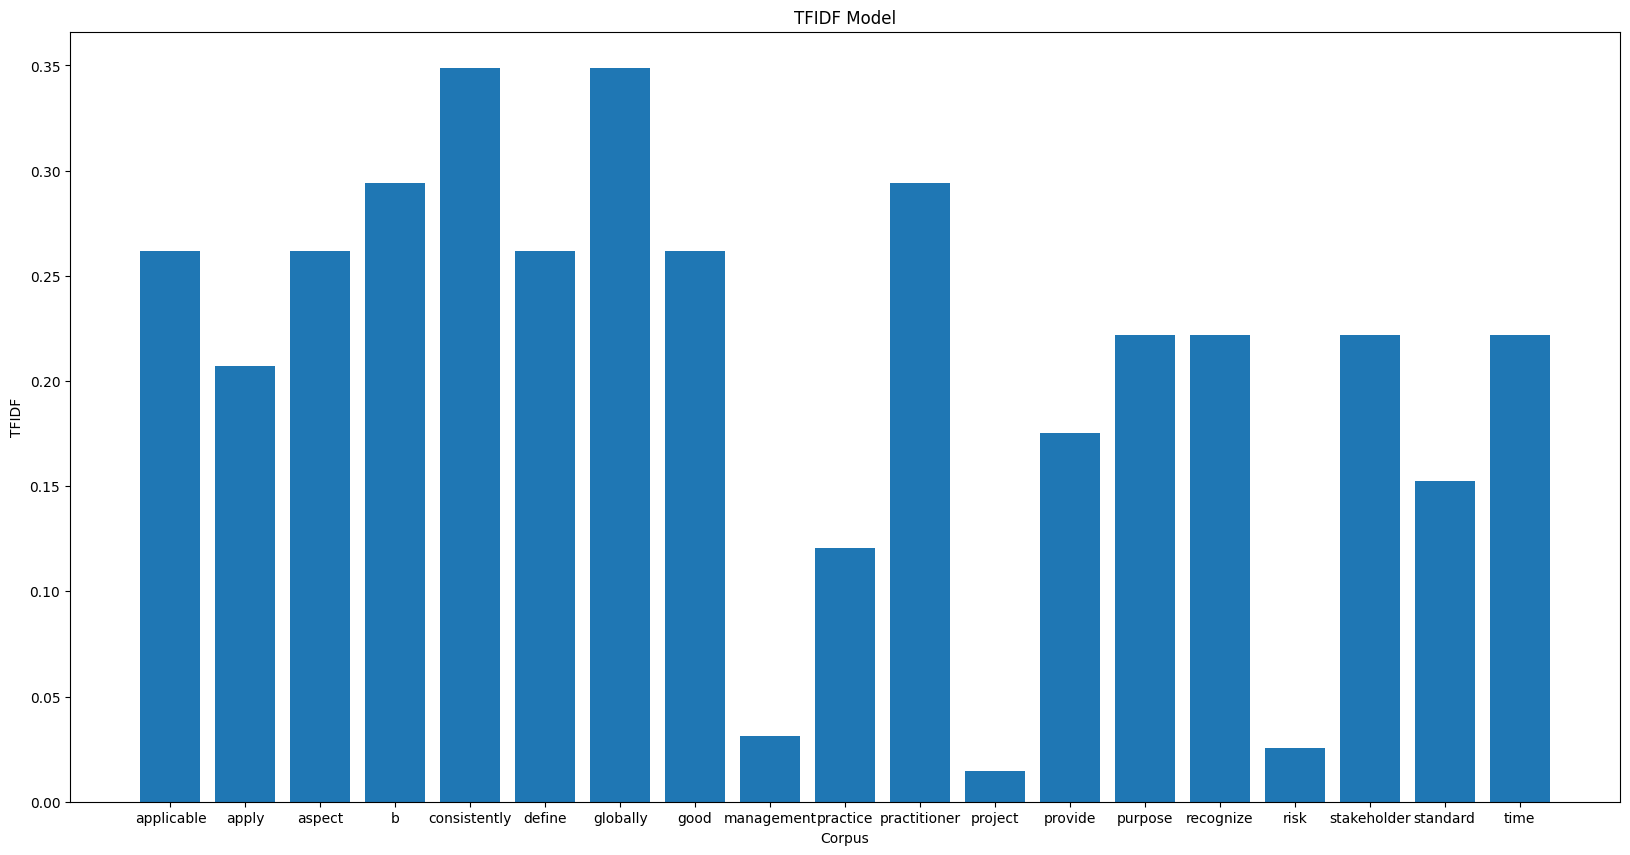

In [47]:
f, ax = plt.subplots(figsize=(20,10))
plt.bar(list(df_tfidf.index.values), list(df_tfidf.TFIDF.values))
plt.xlabel('Corpus')
plt.ylabel('TFIDF')
plt.title('TFIDF Model')

In [48]:
df_pcc['sentence'] = df_pcc['sentence'].apply(correct_extraction_mistakes)
df_pcc['sentence'] = df_pcc['sentence'].apply(remove_single_letter_words)

df_pcc['gram_relations'] = df_pcc['sentence'].apply(extract_grammatical_relations)
df_pcc['sem_relations'] = df_pcc['sentence'].apply(extract_semantic_relations)

df_pcc["processed_sentence"]=df_pcc["sentence"].apply(lambda s : s.lower())
df_pcc["processed_sentence"] = df_pcc["processed_sentence"].apply(lambda s: correct_spelling(s))
df_pcc["processed_sentence"]=df_pcc["processed_sentence"].apply(lambda s : " ".join(lemm(s)))

df_pcc["processed_sentence"]=df_pcc["processed_sentence"].apply(lambda s : remove_punctuation(s))
df_pcc["processed_sentence"]=df_pcc["processed_sentence"].apply(lambda s : remove_stopwords(s))
df_pcc["processed_sentence"] = df_pcc["processed_sentence"].apply(lambda s: remove_duplicates(s))


df_pcc["sentence_tokenized"]=df_pcc["processed_sentence"].apply(lambda s : word_tokenize(s))
df_pcc['entities'] = df_pcc['sentence_tokenized'].apply(process_tokens)
df_pcc['nouns'] = df_pcc['entities'].apply(extract_nouns)
df_pcc['verbs'] = df_pcc['entities'].apply(extract_verbs)
df_pcc['synonyms'] = df_pcc['nouns'].apply(lambda nouns: [get_synonyms(noun) for noun in nouns])
df_pcc['chunks'] = df_pcc['sentence'].apply(chunk_sentence)

In [49]:
df_pcc = df_pcc.drop(index=0).reset_index(drop=True)

In [50]:
frequent_concepts_df = calculate_frequent_concepts(df_pcc)
frequent_concepts_df["Concept"]=frequent_concepts_df["Concept"].apply(lambda s : s.lower())
frequent_concepts_df["Concept"] = frequent_concepts_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
frequent_concepts_df = frequent_concepts_df[~frequent_concepts_df["Concept"].str.contains("figure", case=False, na=False)]
frequent_concepts_df.head(10)

,Concept,Frequency
0,frequency and depth of reviews and updates,2
1,a single stakeholder,2
2,project manager,2
3,project risk management,2
4,both distinct events which are uncertain but c...,1
5,responsibility,1
6,place,1
7,success,1
8,throughout the process,1
9,risk identitication and analysis,1


In [51]:
relations_df = extract_semantic_relations_df(df_pcc)
relations_df["Concept"]=relations_df["Concept"].apply(lambda s : s.lower())
relations_df["Concept"] = relations_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
relations_df = relations_df[~relations_df["Concept"].str.contains("figure", case=False, na=False)]
relations_df

,Concept,Relation,Child_Concept
0,both distinct events which are uncertain but c...,give,risk
1,definition of project risk,encompass,uncertain events which could have a negative e...
2,an individual risk,affect,one or more of the project
3,daytoday project risk management,focus,in order to enhance the prospects of a success...
4,overall project risk,represent,the effect of uncertainty on the project as a ...
5,project stakeholders,set,appropriate project priorities
6,an individual risk or overall project risk,matter,to which
7,risk attitudes of the project stakeholders,determine,the extent to which an individual risk or over...
8,a single stakeholder,adopt,different risk attitudes
9,a single stakeholder,adopt,in the same project


In [52]:
dictionary = corpora.Dictionary(df_pcc['sentence_tokenized'])
corpus = [dictionary.doc2bow(text) for text in df_pcc['sentence_tokenized']]

# Create a TF-IDF model
tfidf_model = TfidfModel(corpus)

# Transform the corpus into TF-IDF representation
tfidf_corpus = tfidf_model[corpus]


df_tfidf = pd.DataFrame(np.array(tfidf_corpus[0])[:,1], index = np.unique(df_pcc.sentence_tokenized.values[0]), columns=['TFIDF'])


Text(0.5, 1.0, 'TFIDF Model')

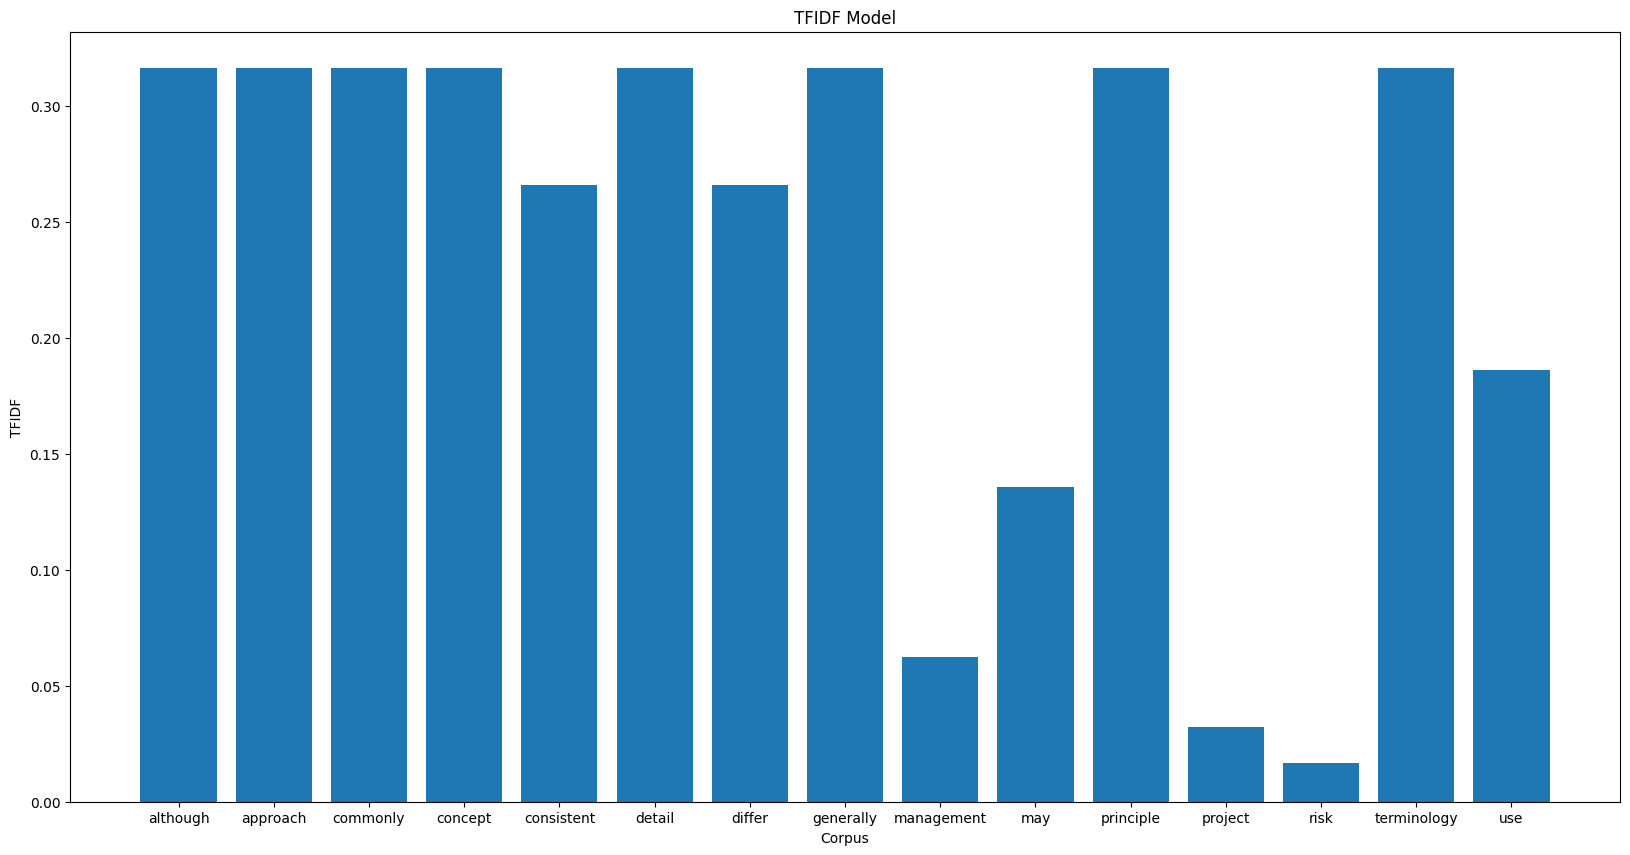

In [53]:
f, ax = plt.subplots(figsize=(20,10))
plt.bar(list(df_tfidf.index.values), list(df_tfidf.TFIDF.values))
plt.xlabel('Corpus')
plt.ylabel('TFIDF')
plt.title('TFIDF Model')

In [54]:
all_nouns = [noun for nouns_list in df_pcc['nouns'] for noun in nouns_list]
noun_freq = Counter(all_nouns)
print(noun_freq.most_common(10))

[('risk', 60), ('project', 50), ('management', 31), ('process', 18), ('stakeholder', 11), ('responsibility', 7), ('event', 6), ('effect', 6), ('action', 6), ('objective', 5)]


In [55]:
df_iprmp['sentence'] = df_iprmp['sentence'].apply(correct_extraction_mistakes)
df_iprmp['sentence'] = df_iprmp['sentence'].apply(remove_single_letter_words)

df_iprmp['gram_relations'] = df_iprmp['sentence'].apply(extract_grammatical_relations)
df_iprmp['sem_relations'] = df_iprmp['sentence'].apply(extract_semantic_relations)

df_iprmp["processed_sentence"]=df_iprmp["sentence"].apply(lambda s : s.lower())
df_iprmp["processed_sentence"] = df_iprmp["processed_sentence"].apply(lambda s: correct_spelling(s))
df_iprmp["processed_sentence"]=df_iprmp["processed_sentence"].apply(lambda s : " ".join(lemm(s)))

df_iprmp["processed_sentence"]=df_iprmp["processed_sentence"].apply(lambda s : remove_punctuation(s))
df_iprmp["processed_sentence"]=df_iprmp["processed_sentence"].apply(lambda s : remove_stopwords(s))
df_iprmp["processed_sentence"] = df_iprmp["processed_sentence"].apply(lambda s: remove_duplicates(s))


df_iprmp["sentence_tokenized"]=df_iprmp["processed_sentence"].apply(lambda s : word_tokenize(s))
df_iprmp['entities'] = df_iprmp['sentence_tokenized'].apply(process_tokens)
df_iprmp['nouns'] = df_iprmp['entities'].apply(extract_nouns)
df_iprmp['verbs'] = df_iprmp['entities'].apply(extract_verbs)
df_iprmp['synonyms'] = df_iprmp['nouns'].apply(lambda nouns: [get_synonyms(noun) for noun in nouns])
df_iprmp['chunks'] = df_iprmp['sentence'].apply(chunk_sentence)

In [ ]:
df_iprmp.head()

In [56]:
frequent_concepts_df = calculate_frequent_concepts(df_iprmp)
frequent_concepts_df["Concept"]=frequent_concepts_df["Concept"].apply(lambda s : s.lower())
frequent_concepts_df["Concept"] = frequent_concepts_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
frequent_concepts_df = frequent_concepts_df[~frequent_concepts_df["Concept"].str.contains("figure", case=False, na=False)]
frequent_concepts_df.head()

,Concept,Frequency
0,project risk management,3
1,defined steps of project risk management,2
2,risk owner,2
3,project risk management process,2
4,monitor and control risks chapter implements a...,2


In [57]:
relations_df = extract_semantic_relations_df(df_iprmp)
relations_df["Concept"]=relations_df["Concept"].apply(lambda s : s.lower())
relations_df["Concept"] = relations_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
relations_df = relations_df[~relations_df["Concept"].str.contains("figure", case=False, na=False)]
relations_df

,Concept,Relation,Child_Concept
0,planning cost control task allocation,earn,value analysis monitoring and review meetings etc
1,each of these elements of project management,have,a role in defining or controlling the uncertai...
2,project risk management,provide,an approach by which uncertainty can be unders...
3,project risk management,require,input from other project management processes
4,project risk management,require,In addition effective
5,outputs such as the work breakdown structure wbs,estimate,etc
6,defined steps of project risk management,describe,a structured approach for understanding and ma...
7,defined steps of project risk management,describe,on a project
8,risks,exist,in relation to objectives
9,scalable elements of the process,include,Available resources Methodology and processes


In [58]:
dictionary = corpora.Dictionary(df_iprmp['sentence_tokenized'])
corpus = [dictionary.doc2bow(text) for text in df_iprmp['sentence_tokenized']]

# Create a TF-IDF model
tfidf_model = TfidfModel(corpus)

# Transform the corpus into TF-IDF representation
tfidf_corpus = tfidf_model[corpus]


df_tfidf = pd.DataFrame(np.array(tfidf_corpus[0])[:,1], index = np.unique(df_iprmp.sentence_tokenized.values[0]), columns=['TFIDF'])


Text(0.5, 1.0, 'TFIDF Model')

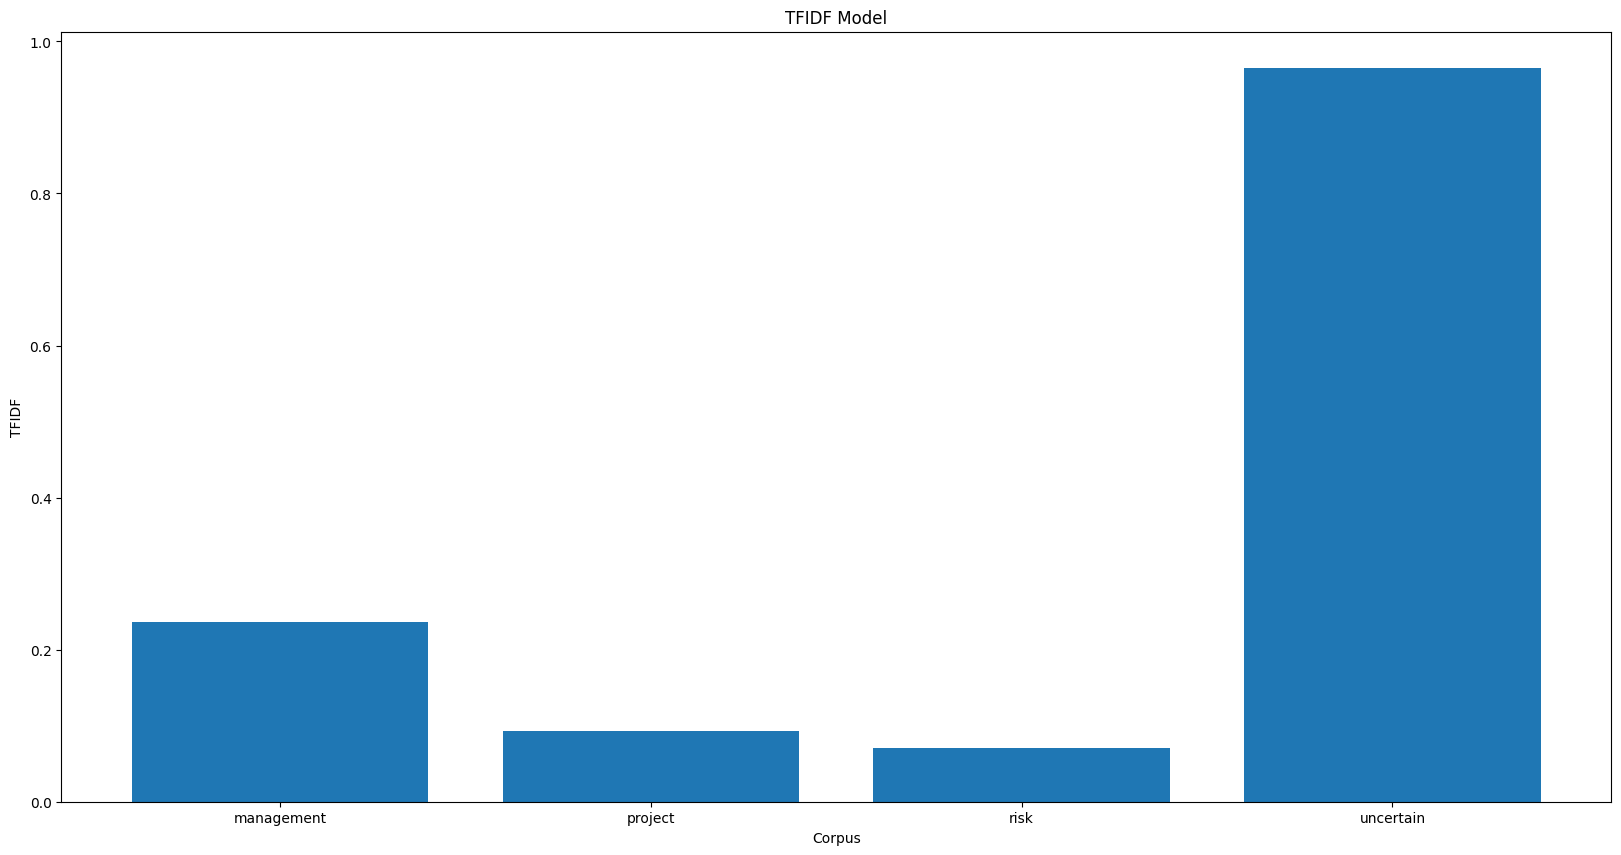

In [59]:
f, ax = plt.subplots(figsize=(20,10))
plt.bar(list(df_tfidf.index.values), list(df_tfidf.TFIDF.values))
plt.xlabel('Corpus')
plt.ylabel('TFIDF')
plt.title('TFIDF Model')

In [60]:
all_nouns = [noun for nouns_list in df_iprmp['nouns'] for noun in nouns_list]
noun_freq = Counter(all_nouns)
print(noun_freq.most_common(10))

[('risk', 55), ('project', 52), ('management', 32), ('process', 24), ('action', 12), ('technique', 11), ('response', 9), ('stakeholder', 8), ('use', 7), ('strategy', 7)]


In [61]:
df_prm['sentence'] = df_prm['sentence'].apply(correct_extraction_mistakes)
df_prm['sentence'] = df_prm['sentence'].apply(remove_single_letter_words)

df_prm['gram_relations'] = df_prm['sentence'].apply(extract_grammatical_relations)
df_prm['sem_relations'] = df_prm['sentence'].apply(extract_semantic_relations)

df_prm["processed_sentence"]=df_prm["sentence"].apply(lambda s : s.lower())
df_prm["processed_sentence"] = df_prm["processed_sentence"].apply(lambda s: correct_spelling(s))
df_prm["processed_sentence"]=df_prm["processed_sentence"].apply(lambda s : " ".join(lemm(s)))

df_prm["processed_sentence"]=df_prm["processed_sentence"].apply(lambda s : remove_punctuation(s))
df_prm["processed_sentence"]=df_prm["processed_sentence"].apply(lambda s : remove_stopwords(s))
df_prm["processed_sentence"] = df_prm["processed_sentence"].apply(lambda s: remove_duplicates(s))


df_prm["sentence_tokenized"]=df_prm["processed_sentence"].apply(lambda s : word_tokenize(s))
df_prm['entities'] = df_prm['sentence_tokenized'].apply(process_tokens)
df_prm['nouns'] = df_prm['entities'].apply(extract_nouns)
df_prm['verbs'] = df_prm['entities'].apply(extract_verbs)
df_prm['synonyms'] = df_prm['nouns'].apply(lambda nouns: [get_synonyms(noun) for noun in nouns])
df_prm['chunks'] = df_prm['sentence'].apply(chunk_sentence)

In [ ]:
df_prm.head()

In [62]:
frequent_concepts_df = calculate_frequent_concepts(df_prm)
frequent_concepts_df["Concept"]=frequent_concepts_df["Concept"].apply(lambda s : s.lower())
frequent_concepts_df["Concept"] = frequent_concepts_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
frequent_concepts_df = frequent_concepts_df[~frequent_concepts_df["Concept"].str.contains("figure", case=False, na=False)]
frequent_concepts_df.head(10)

,Concept,Frequency
0,risk management plan,7
1,plan,4
2,related communication,2
3,risk management plan,2
4,effective risk management,1
5,frequency and scope of the various risk manage...,1
6,type and level of risk detail to be addressed ...,1
7,intensity of effort and the frequency with whi...,1
8,effectively the project team and other stakeho...,1
9,in order for the project risk management proce...,1


In [63]:
relations_df = extract_semantic_relations_df(df_prm)
relations_df["Concept"]=relations_df["Concept"].apply(lambda s : s.lower())
relations_df["Concept"] = relations_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
relations_df = relations_df[~relations_df["Concept"].str.contains("figure", case=False, na=False)]
relations_df

,Concept,Relation,Child_Concept
0,effective risk management,require,creation of a risk management plan
1,approved budget for risk management,be,under which
2,risk management plan,ne,the monitoring methods
3,risk management plan,ne,for repeating the processes as well as speci c...
4,risk management plan,ne,both the normal frequency
5,stakeholders,agree,on an acceptable level of results for the proj...
6,risk management plan,present,with reference to the project definition docum...
7,risk responses stakeholders,prioritize,each project objective
8,measures for success in project risk management,depend,on a number of factors such as the inherent le...
9,project risk management process for a research...,need,For example


In [64]:
dictionary = corpora.Dictionary(df_prm['sentence_tokenized'])
corpus = [dictionary.doc2bow(text) for text in df_prm['sentence_tokenized']]

# Create a TF-IDF model
tfidf_model = TfidfModel(corpus)

# Transform the corpus into TF-IDF representation
tfidf_corpus = tfidf_model[corpus]


df_tfidf = pd.DataFrame(np.array(tfidf_corpus[0])[:,1], index = np.unique(df_prm.sentence_tokenized.values[0]), columns=['TFIDF'])


Text(0.5, 1.0, 'TFIDF Model')

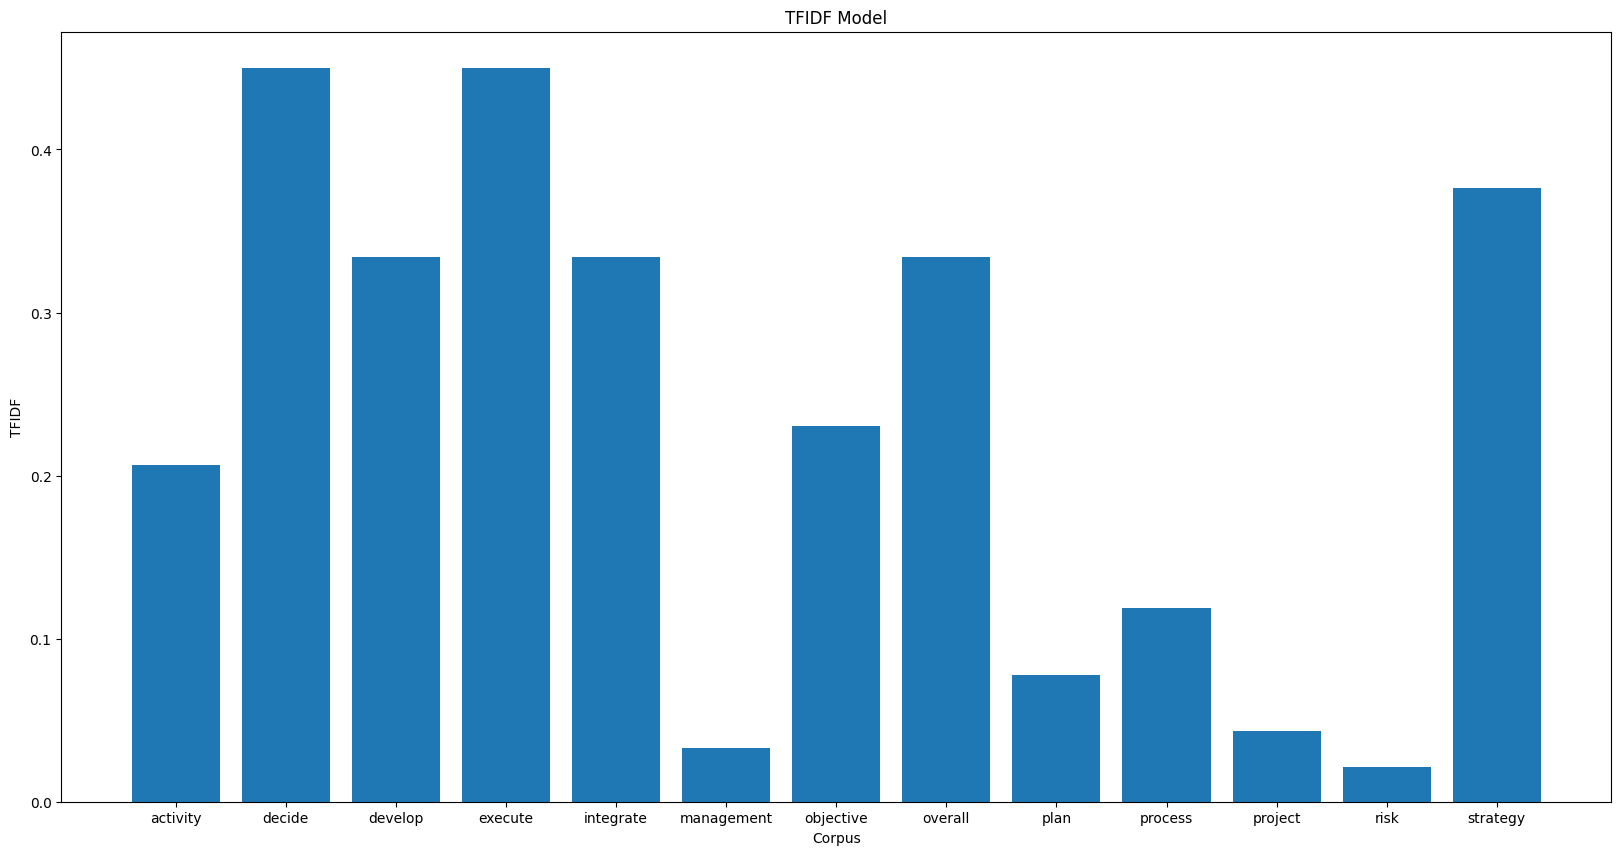

In [65]:
f, ax = plt.subplots(figsize=(20,10))
plt.bar(list(df_tfidf.index.values), list(df_tfidf.TFIDF.values))
plt.xlabel('Corpus')
plt.ylabel('TFIDF')
plt.title('TFIDF Model')

In [66]:
all_nouns = [noun for nouns_list in df_prm['nouns'] for noun in nouns_list]
noun_freq = Counter(all_nouns)
print(noun_freq.most_common(10))

[('risk', 57), ('management', 51), ('project', 45), ('plan', 34), ('process', 23), ('stakeholder', 21), ('activity', 10), ('level', 10), ('organization', 9), ('success', 7)]


In [67]:
df_ir['sentence'] = df_ir['sentence'].apply(correct_extraction_mistakes)
df_ir['sentence'] = df_ir['sentence'].apply(remove_single_letter_words)

df_ir['gram_relations'] = df_ir['sentence'].apply(extract_grammatical_relations)
df_ir['sem_relations'] = df_ir['sentence'].apply(extract_semantic_relations)

df_ir["processed_sentence"]=df_ir["sentence"].apply(lambda s : s.lower())
df_ir["processed_sentence"] = df_ir["processed_sentence"].apply(lambda s: correct_spelling(s))
df_ir["processed_sentence"]=df_ir["processed_sentence"].apply(lambda s : " ".join(lemm(s)))

df_ir["processed_sentence"]=df_ir["processed_sentence"].apply(lambda s : remove_punctuation(s))
df_ir["processed_sentence"]=df_ir["processed_sentence"].apply(lambda s : remove_stopwords(s))
df_ir["processed_sentence"] = df_ir["processed_sentence"].apply(lambda s: remove_duplicates(s))


df_ir["sentence_tokenized"]=df_ir["processed_sentence"].apply(lambda s : word_tokenize(s))
df_ir['entities'] = df_ir['sentence_tokenized'].apply(process_tokens)
df_ir['nouns'] = df_ir['entities'].apply(extract_nouns)
df_ir['verbs'] = df_ir['entities'].apply(extract_verbs)
df_ir['synonyms'] = df_ir['nouns'].apply(lambda nouns: [get_synonyms(noun) for noun in nouns])
df_ir['chunks'] = df_ir['sentence'].apply(chunk_sentence)

In [ ]:
df_ir.head()

In [69]:
frequent_concepts_df = calculate_frequent_concepts(df_ir)
frequent_concepts_df["Concept"]=frequent_concepts_df["Concept"].apply(lambda s : s.lower())
frequent_concepts_df["Concept"] = frequent_concepts_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
frequent_concepts_df = frequent_concepts_df[~frequent_concepts_df["Concept"].str.contains("figure", case=False, na=False)]
frequent_concepts_df.head(10)

,Concept,Frequency
0,pmbok guide,2
1,identify risks process,2
2,fact that some risks are unknowable or emergent,1
3,identify risks process for a particular project,1
4,current assessment techniques,1
5,on outside reference points,1
6,outcomes or effectiveness of these techniques,1
7,on the ability of participants to think creati...,1
8,each category of risk identitication technique,1
9,strengths and weaknesses and no single technique,1


In [ ]:
relations_df = extract_semantic_relations_df(df_ir)
relations_df["Concept"]=relations_df["Concept"].apply(lambda s : s.lower())
relations_df["Concept"] = relations_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
relations_df = relations_df[~relations_df["Concept"].str.contains("figure", case=False, na=False)]
relations_df

In [ ]:
dictionary = corpora.Dictionary(df_ir['sentence_tokenized'])
corpus = [dictionary.doc2bow(text) for text in df_ir['sentence_tokenized']]

# Create a TF-IDF model
tfidf_model = TfidfModel(corpus)

# Transform the corpus into TF-IDF representation
tfidf_corpus = tfidf_model[corpus]


df_tfidf = pd.DataFrame(np.array(tfidf_corpus[0])[:,1], index = np.unique(df_ir.sentence_tokenized.values[0]), columns=['TFIDF'])


In [ ]:
f, ax = plt.subplots(figsize=(20,10))
plt.bar(list(df_tfidf.index.values), list(df_tfidf.TFIDF.values))
plt.xlabel('Corpus')
plt.ylabel('TFIDF')
plt.title('TFIDF Model')

In [ ]:
all_nouns = [noun for nouns_list in df_ir['nouns'] for noun in nouns_list]
noun_freq = Counter(all_nouns)
print(noun_freq.most_common(10))

In [71]:
df_pqra['sentence'] = df_pqra['sentence'].apply(correct_extraction_mistakes)
df_pqra['sentence'] = df_pqra['sentence'].apply(remove_single_letter_words)

df_pqra['gram_relations'] = df_pqra['sentence'].apply(extract_grammatical_relations)
df_pqra['sem_relations'] = df_pqra['sentence'].apply(extract_semantic_relations)

df_pqra["processed_sentence"]=df_pqra["sentence"].apply(lambda s : s.lower())
df_pqra["processed_sentence"] = df_pqra["processed_sentence"].apply(lambda s: correct_spelling(s))
df_pqra["processed_sentence"]=df_pqra["processed_sentence"].apply(lambda s : " ".join(lemm(s)))

df_pqra["processed_sentence"]=df_pqra["processed_sentence"].apply(lambda s : remove_punctuation(s))
df_pqra["processed_sentence"]=df_pqra["processed_sentence"].apply(lambda s : remove_stopwords(s))
df_pqra["processed_sentence"] = df_pqra["processed_sentence"].apply(lambda s: remove_duplicates(s))


df_pqra["sentence_tokenized"]=df_pqra["processed_sentence"].apply(lambda s : word_tokenize(s))
df_pqra['entities'] = df_pqra['sentence_tokenized'].apply(process_tokens)
df_pqra['nouns'] = df_pqra['entities'].apply(extract_nouns)
df_pqra['verbs'] = df_pqra['entities'].apply(extract_verbs)
df_pqra['synonyms'] = df_pqra['nouns'].apply(lambda nouns: [get_synonyms(noun) for noun in nouns])
df_pqra['chunks'] = df_pqra['sentence'].apply(chunk_sentence)

In [ ]:
df_pqra.head()

In [72]:
frequent_concepts_df = calculate_frequent_concepts(df_pqra)
frequent_concepts_df["Concept"]=frequent_concepts_df["Concept"].apply(lambda s : s.lower())
frequent_concepts_df["Concept"] = frequent_concepts_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
frequent_concepts_df = frequent_concepts_df[~frequent_concepts_df["Concept"].str.contains("figure", case=False, na=False)]
frequent_concepts_df.head()

,Concept,Frequency
0,use of definitions for example of levels of pr...,2
1,perform qualitative risk analysis process,2
2,such it,1
3,a risks importance from a combination of proba...,1
4,data collection and evaluation tools including...,1


In [73]:
relations_df = extract_semantic_relations_df(df_pqra)
relations_df["Concept"]=relations_df["Concept"].apply(lambda s : s.lower())
relations_df["Concept"] = relations_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
relations_df = relations_df[~relations_df["Concept"].str.contains("figure", case=False, na=False)]
relations_df

,Concept,Relation,Child_Concept
0,such it,address,the overall risk to project objectives that re...
1,budget or a particular deliverables scope faci...,focus,in these areas
2,nitions,enable,highquality information to be collected
3,indicators of urgency,include,the lead time necessary to execute a risk resp...
4,a risk,increase,in importance
5,use of definitions for example of levels of pr...,assist,in giving realistic assessments for each risk ...
6,use of definitions for example of levels of pr...,assist,the providers of the information
7,data,gather,from individuals
8,tools and techniques used for assessing indivi...,identify,the risks that are important to the projects s...
9,ne risks importance qualitative risk analysis ...,provide,ways to distinguish those risks that are impor...


In [ ]:
all_nouns = [noun for nouns_list in df_pqra['nouns'] for noun in nouns_list]
noun_freq = Counter(all_nouns)
print(noun_freq.most_common(10))

In [74]:
df_pqraa['sentence'] = df_pqraa['sentence'].apply(correct_extraction_mistakes)
df_pqraa['sentence'] = df_pqraa['sentence'].apply(remove_single_letter_words)

df_pqraa['gram_relations'] = df_pqraa['sentence'].apply(extract_grammatical_relations)
df_pqraa['sem_relations'] = df_pqraa['sentence'].apply(extract_semantic_relations)

df_pqraa["processed_sentence"]=df_pqraa["sentence"].apply(lambda s : s.lower())
df_pqraa["processed_sentence"] = df_pqraa["processed_sentence"].apply(lambda s: correct_spelling(s))
df_pqraa["processed_sentence"]=df_pqraa["processed_sentence"].apply(lambda s : " ".join(lemm(s)))

df_pqraa["processed_sentence"]=df_pqraa["processed_sentence"].apply(lambda s : remove_punctuation(s))
df_pqraa["processed_sentence"]=df_pqraa["processed_sentence"].apply(lambda s : remove_stopwords(s))
df_pqraa["processed_sentence"] = df_pqraa["processed_sentence"].apply(lambda s: remove_duplicates(s))


df_pqraa["sentence_tokenized"]=df_pqraa["processed_sentence"].apply(lambda s : word_tokenize(s))
df_pqraa['entities'] = df_pqraa['sentence_tokenized'].apply(process_tokens)
df_pqraa['nouns'] = df_pqraa['entities'].apply(extract_nouns)
df_pqraa['verbs'] = df_pqraa['entities'].apply(extract_verbs)
df_pqraa['synonyms'] = df_pqraa['nouns'].apply(lambda nouns: [get_synonyms(noun) for noun in nouns])
df_pqraa['chunks'] = df_pqraa['sentence'].apply(chunk_sentence)

In [ ]:
df_pqraa.head()

In [75]:
frequent_concepts_df = calculate_frequent_concepts(df_pqraa)
frequent_concepts_df["Concept"]=frequent_concepts_df["Concept"].apply(lambda s : s.lower())
frequent_concepts_df["Concept"] = frequent_concepts_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
frequent_concepts_df = frequent_concepts_df[~frequent_concepts_df["Concept"].str.contains("figure", case=False, na=False)]
frequent_concepts_df.head()

,Concept,Frequency
0,partial risk analyses such as qualitative risk...,2
1,analyzing uncertainty in the project using qua...,2
2,results of the analysis,2
3,qualitative risk analysis,2
4,quantified risks,2


In [76]:
relations_df = extract_semantic_relations_df(df_pqraa)
relations_df

,Concept,Relation,Child_Concept
0,The Perform Quantitative Risk Analysis process,provide,a numerical estimate of the overall effect of ...
1,analyzing uncertainty in the project using qua...,provide,more realism
2,analyzing uncertainty in the project using qua...,provide,in the estimate of the overall project cost or...
3,qualitative risk analysis,provide,enough information for development of effectiv...
4,qualitative risk analysis,provide,especially for smaller projects
5,the additional insights and value,justify,the additional effort
6,Partial risk analyses such as qualitative risk...,view,at a time
7,Partial risk analyses such as qualitative risk...,view,one
8,The implementation of overall risk analysis us...,require,Complete and accurate representation of the pr...
9,Examples of these representations,include,the project schedule or cost estimate


In [ ]:
all_nouns = [noun for nouns_list in df_pqraa['nouns'] for noun in nouns_list]
noun_freq = Counter(all_nouns)
print(noun_freq.most_common(10))

In [77]:
df_prr['sentence'] = df_prr['sentence'].apply(correct_extraction_mistakes)
df_prr['sentence'] = df_prr['sentence'].apply(remove_single_letter_words)

df_prr['gram_relations'] = df_prr['sentence'].apply(extract_grammatical_relations)
df_prr['sem_relations'] = df_prr['sentence'].apply(extract_semantic_relations)

df_prr["transformed_sentence"]=df_prr["sentence"].apply(lambda s : s.lower())
df_prr["transformed_sentence"] = df_prr["transformed_sentence"].apply(lambda s: correct_spelling(s))
df_prr["transformed_sentence"]=df_prr["transformed_sentence"].apply(lambda s : " ".join(lemm(s)))

df_prr["transformed_sentence"]=df_prr["transformed_sentence"].apply(lambda s : remove_punctuation(s))
df_prr["transformed_sentence"]=df_prr["transformed_sentence"].apply(lambda s : remove_stopwords(s))
df_prr["transformed_sentence"] = df_prr["transformed_sentence"].apply(lambda s: remove_duplicates(s))


df_prr["sentence_tokenized"]=df_prr["transformed_sentence"].apply(lambda s : word_tokenize(s))
df_prr['entities'] = df_prr['sentence_tokenized'].apply(process_tokens)
df_prr['nouns'] = df_prr['entities'].apply(extract_nouns)
df_prr['verbs'] = df_prr['entities'].apply(extract_verbs)
df_prr['synonyms'] = df_prr['nouns'].apply(lambda nouns: [get_synonyms(noun) for noun in nouns])
df_prr['chunks'] = df_prr['sentence'].apply(chunk_sentence)

In [ ]:
df_prr.head()

In [78]:
frequent_concepts_df = calculate_frequent_concepts(df_prr)
frequent_concepts_df["Concept"]=frequent_concepts_df["Concept"].apply(lambda s : s.lower())
frequent_concepts_df["Concept"] = frequent_concepts_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
frequent_concepts_df = frequent_concepts_df[~frequent_concepts_df["Concept"].str.contains("figure", case=False, na=False)]
frequent_concepts_df.head()

,Concept,Frequency
0,response specification for each such risk,2
1,senior management,2
2,selection process,2
3,customer and the supplier,2
4,risk action owners,1


In [79]:
relations_df = extract_semantic_relations_df(df_prr)
relations_df["Concept"]=relations_df["Concept"].apply(lambda s : s.lower())
relations_df["Concept"] = relations_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
relations_df = relations_df[~relations_df["Concept"].str.contains("figure", case=False, na=False)]
relations_df

,Concept,Relation,Child_Concept
0,response specification for each such risk,include,a description of any corresponding trigger con...
1,response specification for each such risk,include,For this reason
2,responses when implemented,have,potential effects on the project objectives
3,management,take,ownership of risks with political organization...
4,senior management,approve,riskrelated contingency reserves
5,senior management,approve,In addition
6,resources costs and duration updating the budg...,obtain,approval from management
7,risks,aggregate,during the Perform Quantitative Risk Analysis ...
8,ten small related risks combined,pose,a big risk to the project
9,risk response planning,combine,responses that address the threats as well as ...


In [ ]:
all_nouns = [noun for nouns_list in df_prr['nouns'] for noun in nouns_list]
noun_freq = Counter(all_nouns)
print(noun_freq.most_common(10))

In [80]:
df_mcr['sentence'] = df_mcr['sentence'].apply(correct_extraction_mistakes)
df_mcr['sentence'] = df_mcr['sentence'].apply(remove_single_letter_words)

df_mcr['gram_relations'] = df_mcr['sentence'].apply(extract_grammatical_relations)
df_mcr['sem_relations'] = df_mcr['sentence'].apply(extract_semantic_relations)

df_mcr["processed_sentence"]=df_mcr["sentence"].apply(lambda s : s.lower())
df_mcr["processed_sentence"] = df_mcr["processed_sentence"].apply(lambda s: correct_spelling(s))
df_mcr["processed_sentence"]=df_mcr["processed_sentence"].apply(lambda s : " ".join(lemm(s)))

df_mcr["processed_sentence"]=df_mcr["processed_sentence"].apply(lambda s : remove_punctuation(s))
df_mcr["processed_sentence"]=df_mcr["processed_sentence"].apply(lambda s : remove_stopwords(s))
df_mcr["processed_sentence"] = df_mcr["processed_sentence"].apply(lambda s: remove_duplicates(s))


df_mcr["sentence_tokenized"]=df_mcr["processed_sentence"].apply(lambda s : word_tokenize(s))
df_mcr['entities'] = df_mcr['sentence_tokenized'].apply(process_tokens)
df_mcr['nouns'] = df_mcr['entities'].apply(extract_nouns)
df_mcr['verbs'] = df_mcr['entities'].apply(extract_verbs)
df_mcr['synonyms'] = df_mcr['nouns'].apply(lambda nouns: [get_synonyms(noun) for noun in nouns])
df_mcr['chunks'] = df_mcr['sentence'].apply(chunk_sentence)

In [ ]:
df_mcr.head()

In [82]:
frequent_concepts_df = calculate_frequent_concepts(df_mcr)
frequent_concepts_df["Concept"]=frequent_concepts_df["Concept"].apply(lambda s : s.lower())
frequent_concepts_df["Concept"] = frequent_concepts_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
frequent_concepts_df = frequent_concepts_df[~frequent_concepts_df["Concept"].str.contains("figure", case=False, na=False)]
frequent_concepts_df.head()

,Concept,Frequency
0,sponsor feedback,2
1,risk action owner,1
2,typical information,1
3,management information,1
4,signi,1


In [83]:
relations_df = extract_semantic_relations_df(df_mcr)
relations_df["Concept"]=relations_df["Concept"].apply(lambda s : s.lower())
relations_df["Concept"] = relations_df["Concept"].str.replace(r"(?i)^\s*the\s+", "", regex=True)
relations_df = relations_df[~relations_df["Concept"].str.contains("figure", case=False, na=False)]
relations_df

,Concept,Relation,Child_Concept
0,risk action owner,keep,the risk owner
1,any barriers to effectiveness or keys to succe...,lead,to improvements in risk management of the curr...
2,project management plan,include,the actions required to monitor and control pr...
3,project schedule,include,all of the agreedupon responserelated actions
4,risk response planning,define,a set of actions to be carried out as part of ...
5,projects seniorlevel sponsor,require,regular reports on the risks and the planned r...
6,sponsor feedback,motivate,by demonstrating seniorlevel interest in Proje...
7,sponsor feedback,motivate,the project team
8,project manager,assess,at any point in the project
9,responses,have,the expected effect on the projects


In [ ]:
all_nouns = [noun for nouns_list in df_mcr['nouns'] for noun in nouns_list]
noun_freq = Counter(all_nouns)
print(noun_freq.most_common(10))

In [ ]:
# from wordcloud import WordCloud

# # Create word cloud from frequencies
# wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_freq)

# # Plot the word cloud
# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud, interpolation='bilinear')
# plt.axis("off")
# plt.show()